# CS5489 - Machine Learning
# Lecture 4a - Supervised Learning - Regression
### Dept. of Computer Science, City University of Hong Kong

# Outline
1. Linear Regression
2. Selecting Features
3. Removing Outliers
4. Non-linear regression

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

# Regression
- Supervised learning
  - Input observation $\mathbf{x}$, typically a vector in $\mathbb{R}^d$.
  - Output $y \in \mathbb{R}$, a real number.
- **Goal:** predict output $y$ from input $\mathbf{x}$.
  - i.e., learn the function $y = f(\mathbf{x})$.

In [2]:
linbias = 30
[linX, linY, lincoefs] = datasets.make_regression(n_samples=100, n_features=1, 
                                                  n_informative=1, bias=linbias, noise=10.0, 
                                                  coef=True, random_state=4487)
axbox = [-3, 3, -60, 100]
linfig = plt.figure()
plt.plot(linX, linY, 'b.')
plt.xlabel('feature x')
plt.ylabel('output y')
plt.grid(True); plt.axis(axbox)
plt.close()

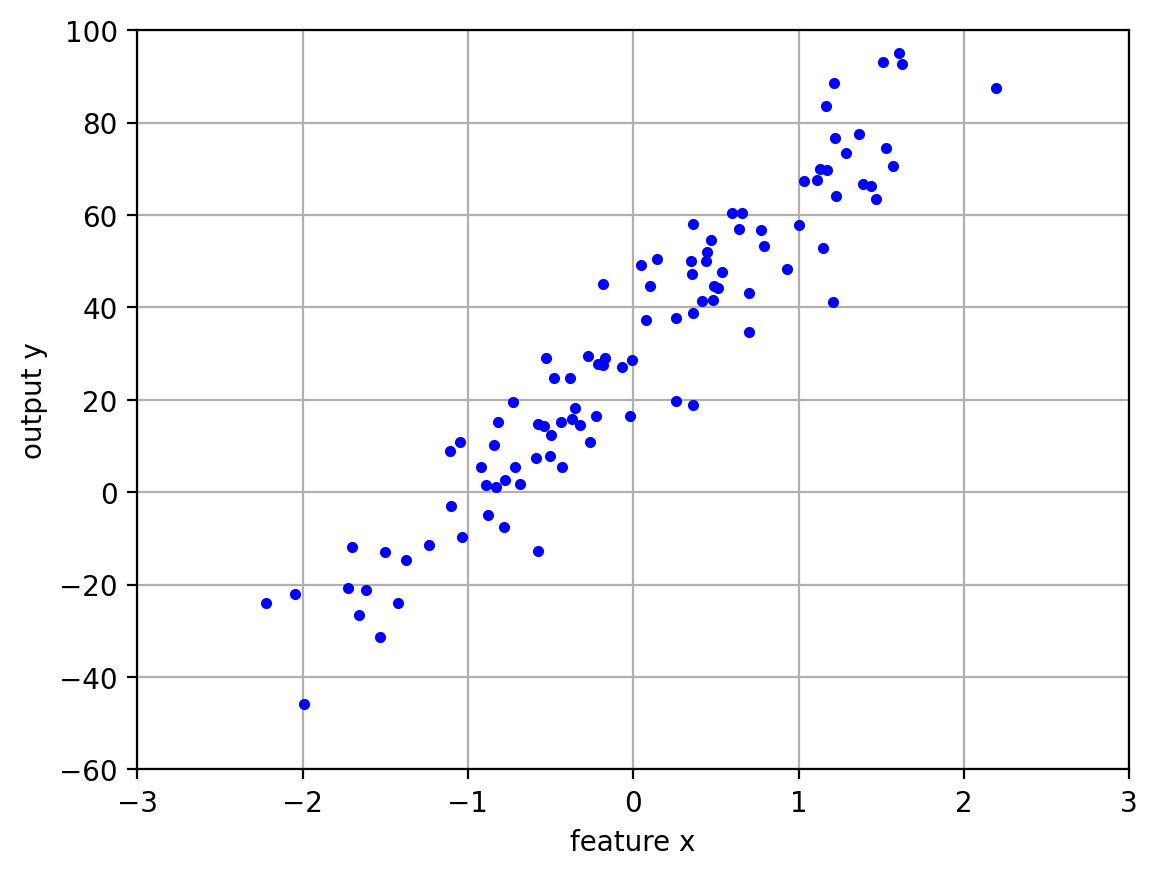

In [3]:
linfig

In [4]:
from sklearn.datasets import fetch_openml
def load_housing(mode=1):
    housing = fetch_openml(name="house_prices", as_frame=True)
    
    # 2-dim data for illustration
    if mode == 1:
        housingY = array(housing['target'])
        housingX = array(housing['data'][["GrLivArea", "YrSold", "YearBuilt",]])

        # get age when sold
        housingX[:,1] -= housingX[:,2]
        housingX = housingX[:,0:2]

        ss = 4   # subsample for illustration
        housingY = housingY[::ss] / 1000
        housingX = housingX[::ss] / [[100,1]]
        
        housingYname = 'Home Price ($1000s)'
        housingXname = ('Living Area (100 sf)', 'Age when sold (Yrs)')
        housingXdesc = ('Living Area (100 sf)', 'Age when sold (Yrs)')
        housingaxbox = ([4.50,37,0,600], [0,140,0,600])
        
    elif (mode==2):
        # data for illustrating feature selection

        housingY = array(housing['target'])
        housingX = array(housing['data'][["GrLivArea", "TotRmsAbvGrd", 
                                          "GarageArea", "TotalBsmtSF", "Fireplaces", 
                                          "BedroomAbvGr", "FullBath",
                                          "LotArea", "LowQualFinSF", 
                                          "OverallQual", "OverallCond", 
                                          "YrSold", "YearBuilt",]])
        # get age when sold
        housingX[:,-2] -= housingX[:,-1]
        housingX = housingX[:,0:-1]

        ss = 4   # subsample for illustration
        housingY = housingY[::ss] / 1000
        housingX = housingX[::ss]
        
        housingYname = 'Home Price ($1000s)'
        housingXname = ["LiveA", "Rooms", 
                        "GaraA", "Bsmt", "Fire", 
                        "Bdrms", "Bath",
                        "LotA", "LowQA", 
                        "Qual", "Cond", 
                         "Age"]
        housingXdesc = ["Living Area (sqf)", "Number of Rooms", "Garage Area (sqf)", 
                       "Basement Area (sqf)", "Number of Fireplaces", "Number of Bedrooms", 
                       "Number of Bathrooms", "Lot Area (sqf)", "Area of low-quality finish (sqf)", 
                       "Overall Quality of Materials", "Overall Condition", "Age when Sold (yrs)"]
        housingaxbox = ()
        
        
    print("target: ", housingY.shape, "; data: ", housingX.shape)
    return housingX, housingY, housingXname, housingYname, housingaxbox, housingXdesc

In [5]:
housingX, housingY, housingXname, housingYname, housingaxbox, housingXdesc = load_housing(mode=1)

housing1dfig = plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(housingX[:,0], housingY, 'b.')
plt.grid(True)
plt.ylabel(housingYname)
plt.xlabel(housingXname[0])

plt.subplot(1,2,2)
plt.plot(housingX[:,1], housingY, 'b.')
plt.grid(True)
plt.ylabel(housingYname)
plt.xlabel(housingXname[1])
plt.close()

housing2dfig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(housingX[:,0], housingX[:,1], c=housingY, edgecolors='k', cmap='jet')
cbar = plt.colorbar()
cbar.set_label(housingYname)
plt.xlabel(housingXname[0])
plt.ylabel(housingXname[1])
plt.grid(True)
plt.close()

ax = housing2dfig.add_subplot(122, projection='3d')
ax.scatter(housingX[:,0], housingX[:,1], c=housingY, edgecolors='k', cmap='jet')
ax.set_xlabel(housingXname[0])
ax.set_ylabel(housingXname[1])
ax.set_zlabel(housingYname)

target:  (365,) ; data:  (365, 2)


Text(0.5, 0, 'Home Price ($1000s)')

# Examples: 
- Predict housing price from living area and house age.

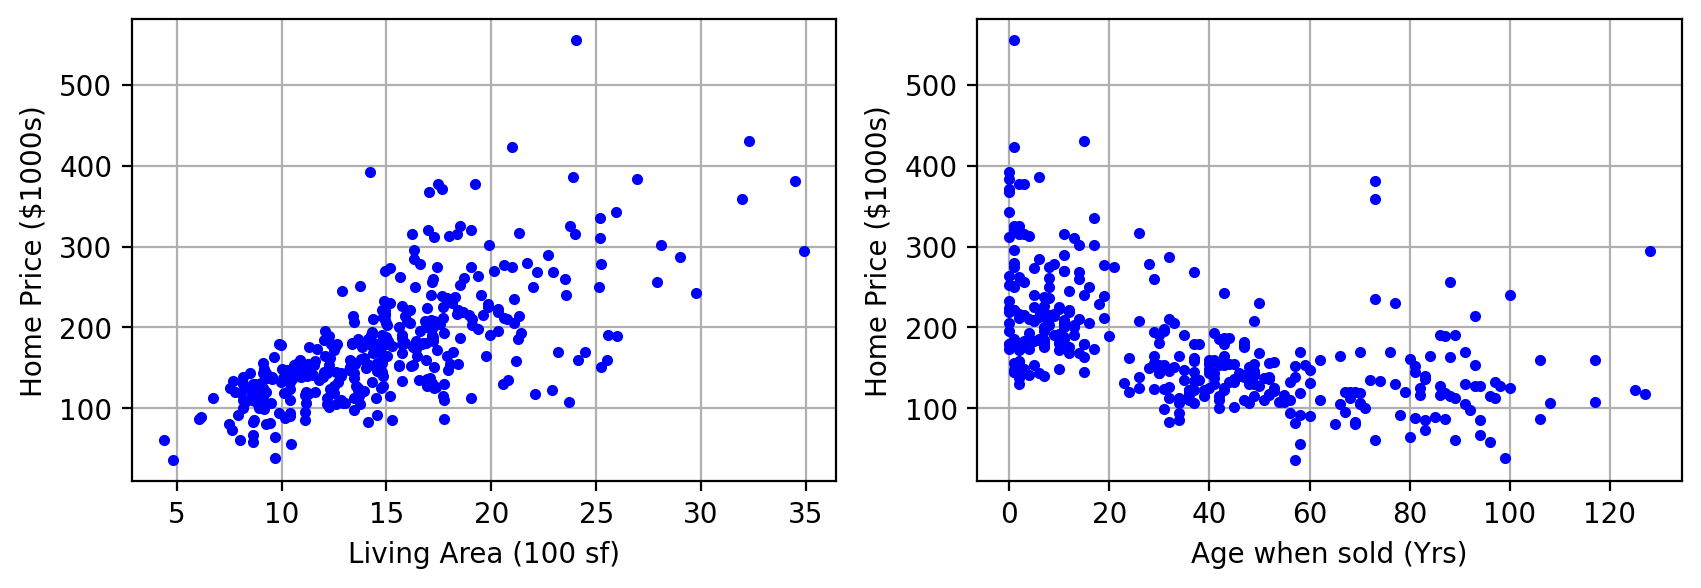

In [6]:
housing1dfig

- predict from both features

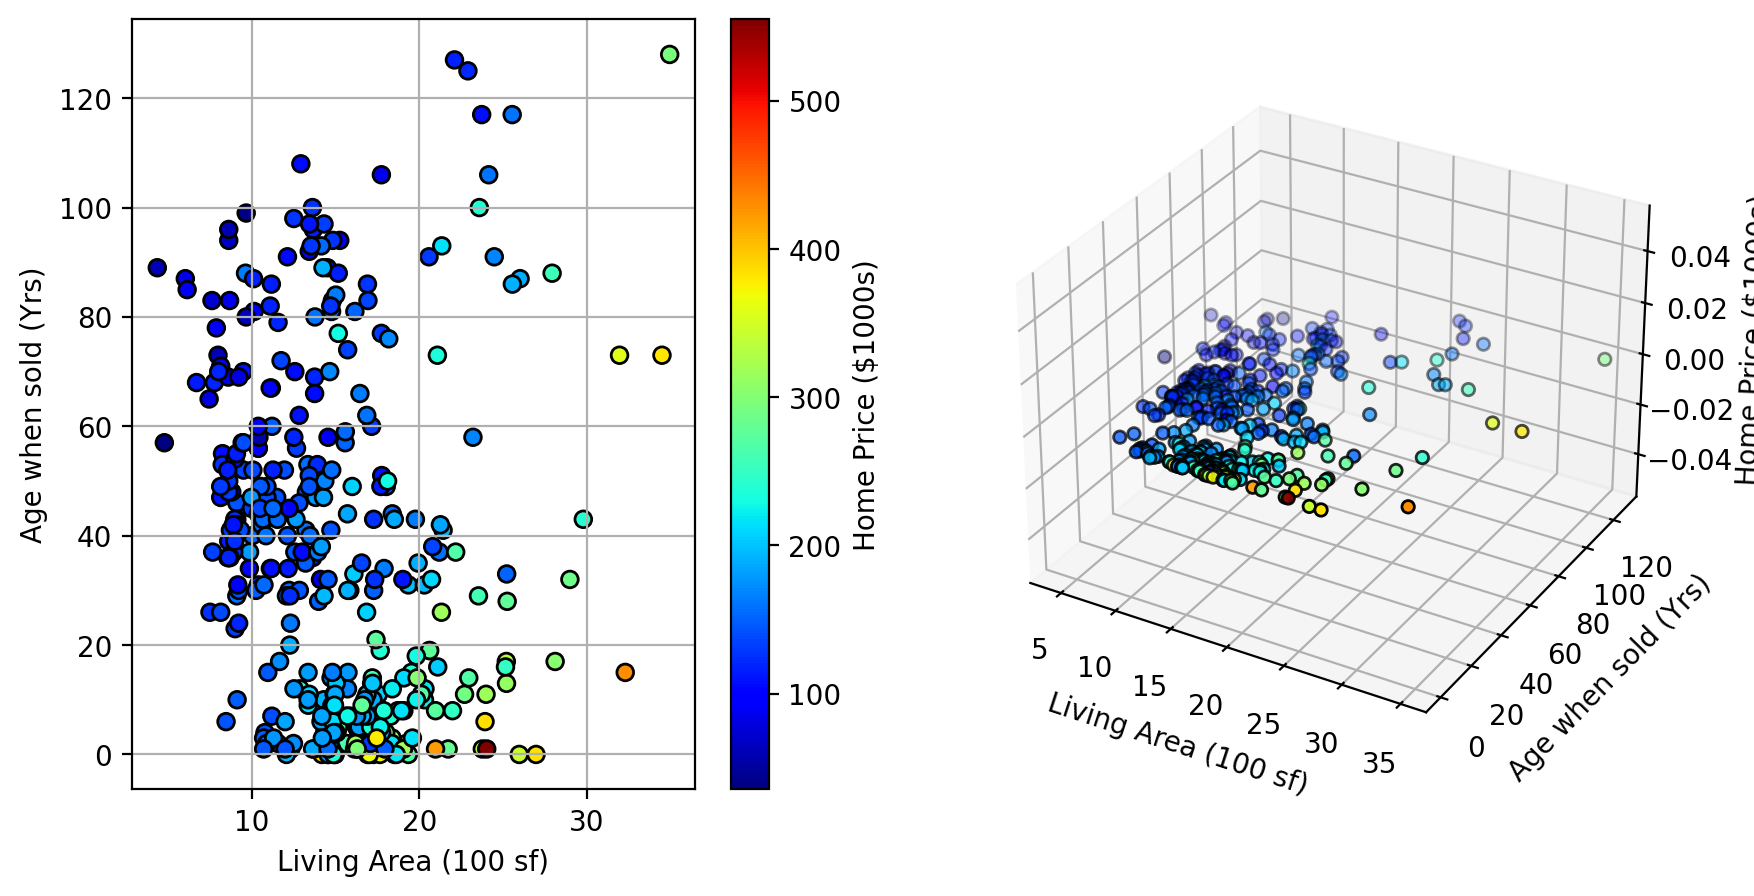

In [7]:
housing2dfig

# Linear Regression 
- **1-d case:** the output $y$ is a linear function of input feature $x$
  - $y = w * x + b $
  - $w$ is the slope, $b$ is the intercept.

In [8]:
linfig = plt.figure()
plt.plot(linX, linY, 'b.')
xr = linspace(axbox[0], axbox[1], 100)
plt.plot(xr, lincoefs*xr+linbias, 'r-', label='y = %0.4g x + %0.4g' % (lincoefs, linbias))
plt.xlabel('feature x')
plt.ylabel('output y')
plt.grid(True); plt.axis(axbox)
plt.legend(loc='lower right')
plt.close()

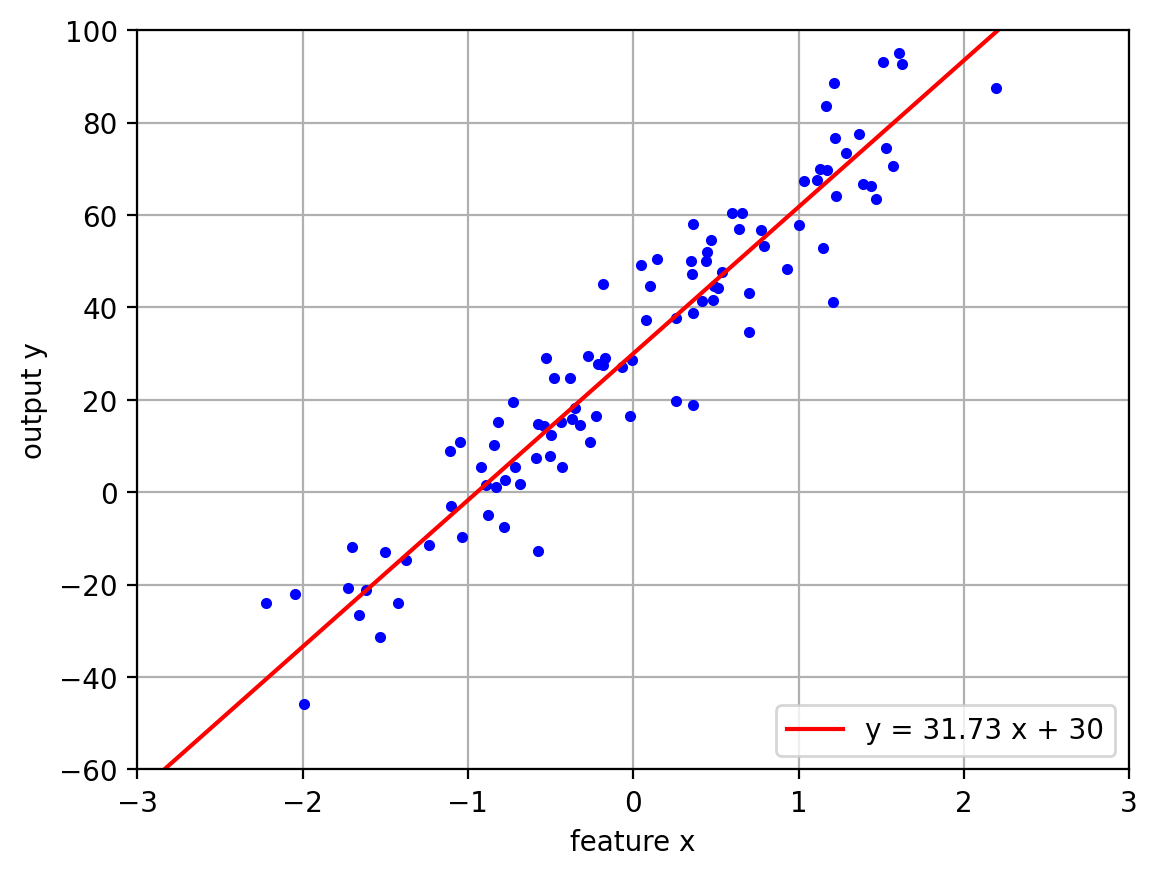

In [9]:
linfig

- **d-dim case**: the output $y$ is a linear combination of $d$ input variables $x_1, \cdots, x_d$:
  - $y = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_d x_d$
- Equivalently, 
  - $y = w_0 + \mathbf{w}^T \mathbf{x} = w_0 +\sum_{j=1}^d w_j x_j$
    - $\mathbf{x}\in\mathbb{R}^d$ is the vector of input values.
    - $\mathbf{w}\in\mathbb{R}^d$ are the weights of the linear function, and $w_0$ is the intercept (bias term).

In [10]:

xr = [linspace(-3,3,100), linspace(-4,4,100)]
xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

w = array([1,2])
b = 20
yout = dot(allpts, w[:,newaxis]) + b
yout = yout.reshape(xgrid0.shape)

lin2dfig = plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(yout, origin='lower', extent=[-3,3,-4,4], cmap='Blues')
cbar.set_label('y')
cbar = plt.colorbar()
CS = plt.contour(xr[0], xr[1], yout, colors='k')
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('$y=x_1 + 2x_2 + 20$')
ax = lin2dfig.add_subplot(122, projection='3d')
ax.plot_surface(xgrid0, xgrid1, yout, cmap='Blues')
ax.contour(xr[0], xr[1], yout, zdir='z', offset=0, colors='k')
ax.set_zlim(0,35)
ax.set_zlabel('y')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.close()

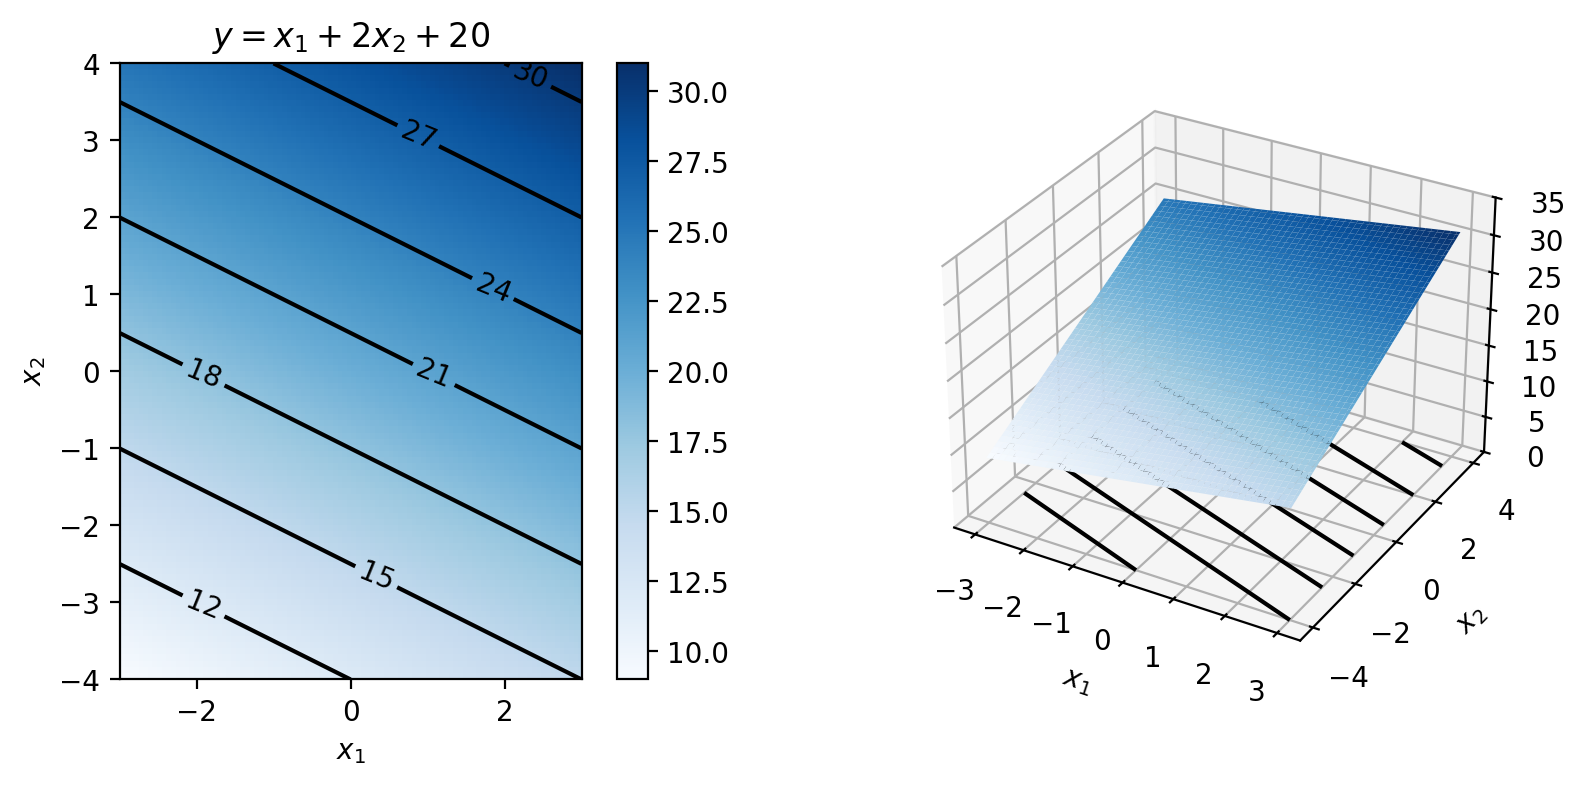

In [11]:
lin2dfig

# Ordinary Least Squares (OLS)
- The linear function has form $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$.
- _How to estimate the parameters $(\mathbf{w},b)$ from the data?_
- Fit the parameters by minimizing the squared prediction error on the training set $\{(\mathbf{x}_i,y_i)\}_{i=1}^N$:
  $$\min_{\mathbf{w},b} \sum_{i=1}^N (y_i - f(\mathbf{x}_i))^2 = \min_{\mathbf{w},b} \sum_{i=1}^N (y_i - (\mathbf{w}^T\mathbf{x}_i + b))^2$$

- The bias term $b$ can be absorbed into $\mathbf{w}$ by redefining as follows:
  - $\mathbf{w} \leftarrow \begin{bmatrix}\mathbf{w}\\b\end{bmatrix}$, $\mathbf{x} \leftarrow \begin{bmatrix}\mathbf{x}\\1\end{bmatrix}$

- We can write the minimization problem as:
$$ \min_{\mathbf{w}} ||\mathbf{y}-\mathbf{X}^T\mathbf{w}||^2$$
  - where $\mathbf{X} = [\mathbf{x}_1 \cdots \mathbf{x}_N]$ is the data matrix,
  - and $\mathbf{y} = [y_1, \cdots, y_N]^T$ is vector of outputs.

- To obtain the solution:
  - Expand the norm term:
$$\begin{aligned}||\mathbf{y}-\mathbf{X}^T\mathbf{w}||^2 &= (\mathbf{y}-\mathbf{X}^T\mathbf{w})^T(\mathbf{y}-\mathbf{X}^T\mathbf{w})\\
&= \mathbf{y}^T\mathbf{y} - 2 \mathbf{y}^T\mathbf{X}^T\mathbf{w} + \mathbf{w}^T\mathbf{X}\mathbf{X}^T\mathbf{w}
\end{aligned}$$
  - Find the minimum by taking the derivative and setting to 0:
$$\begin{aligned}\frac{d}{d\mathbf{w}} (\mathbf{y}^T\mathbf{y} - 2 \mathbf{y}^T\mathbf{X}^T\mathbf{w} + \mathbf{w}^T\mathbf{X}\mathbf{X}^T\mathbf{w})
&= -2\mathbf{X}\mathbf{y}  + 2\mathbf{X}\mathbf{X}^T\mathbf{w} = 0\\
&\Rightarrow \  \mathbf{X}\mathbf{X}^T\mathbf{w} = \mathbf{X}\mathbf{y} \\
&\Rightarrow \  \mathbf{w}^* = (\mathbf{X}\mathbf{X}^T)^{-1}\mathbf{X}\mathbf{y}
\end{aligned}$$
  - closed-form solution!
    - Note: $(\mathbf{X}\mathbf{X}^T)^{-1}\mathbf{X}$ is also called the _pseudo-inverse_ of $\mathbf{X}$.

# Examples: 1-d

In [12]:
def plot_linear_1d(model, axbox, X, Y):
    xr = linspace(axbox[0], axbox[1], 100).reshape(100,1)
    
    # prediction for range of x features
    ypred = model.predict(xr)

    plt.plot(X, Y, 'b.')
    plt.plot(xr, ypred, 'r-')
    plt.grid(True); plt.axis(axbox)

    # calculate mean-square error on training set
    MSE = metrics.mean_squared_error(Y, model.predict(X))
    
    plt.title("w={:.5f}; b={:.5f}\nMSE={:.5f}".format(float(model.coef_), float(model.intercept_), MSE))

/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_24218/4018677310.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("w={:.5f}; b={:.5f}\nMSE={:.5f}".format(float(model.coef_), float(model.intercept_), MSE))


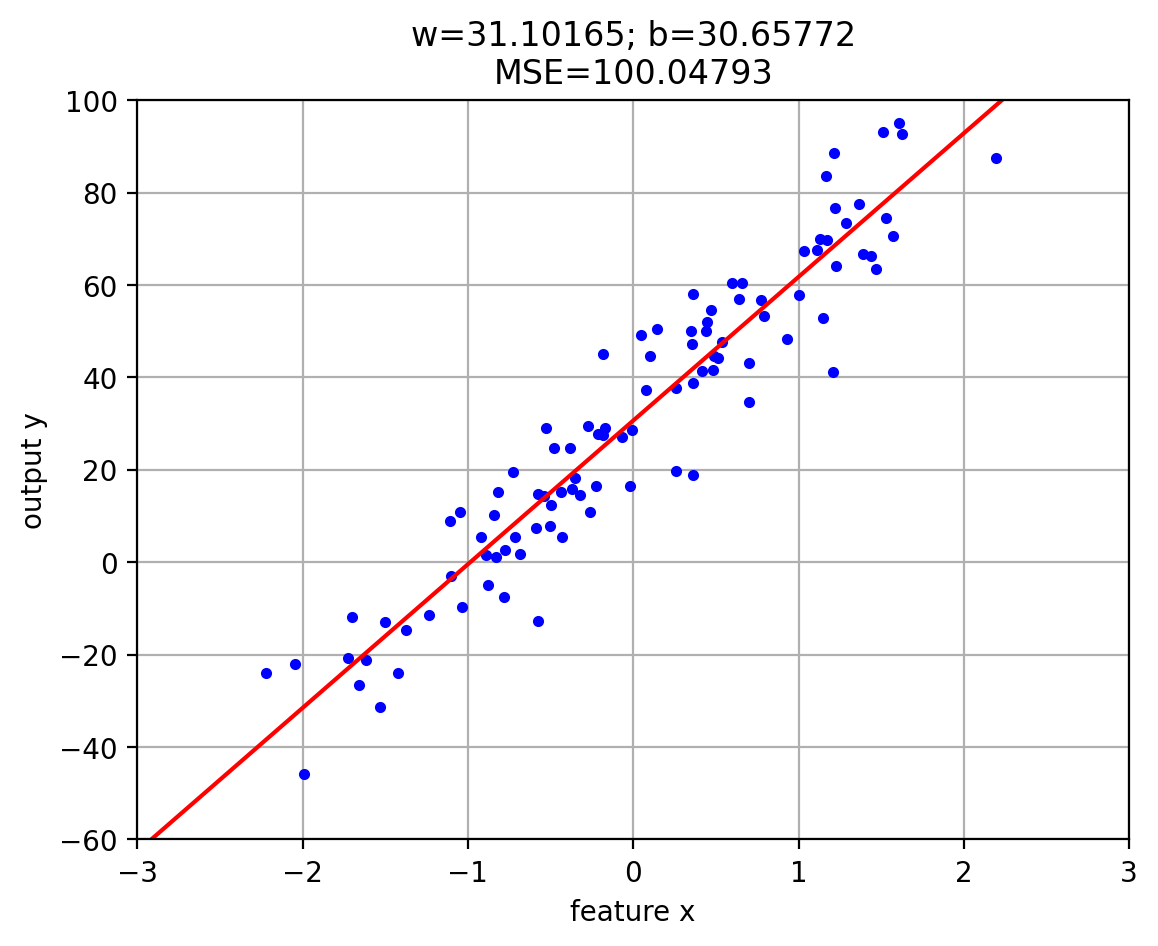

In [13]:
# fit using ordinary least squares
ols = linear_model.LinearRegression()
ols.fit(linX, linY)

# show plot
axbox = [-3, 3, -60, 100]
plt.figure()
plot_linear_1d(ols, axbox, linX, linY)
plt.xlabel('feature x'); plt.ylabel('output y');

# Housing price (1d)
- learn regression function for each feature separately

In [14]:
ols = [None]*2
for i in range(2):
    ols[i] = linear_model.LinearRegression()
    tmpX = housingX[:,i][:,newaxis]
    ols[i].fit(tmpX, housingY)

In [15]:
# fit each dimension of Boston data
ofig = plt.figure(figsize=(10,3))
for i in range(2):
    plt.subplot(1,2,i+1)
    tmpX = housingX[:,i][:,newaxis]
    plot_linear_1d(ols[i], housingaxbox[i], tmpX, housingY)
    plt.ylabel(housingYname); plt.xlabel(housingXname[i])
plt.close()

/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_24218/4018677310.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("w={:.5f}; b={:.5f}\nMSE={:.5f}".format(float(model.coef_), float(model.intercept_), MSE))
/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_24218/4018677310.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("w={:.5f}; b={:.5f}\nMSE={:.5f}".format(float(model.coef_), float(model.intercept_), MSE))


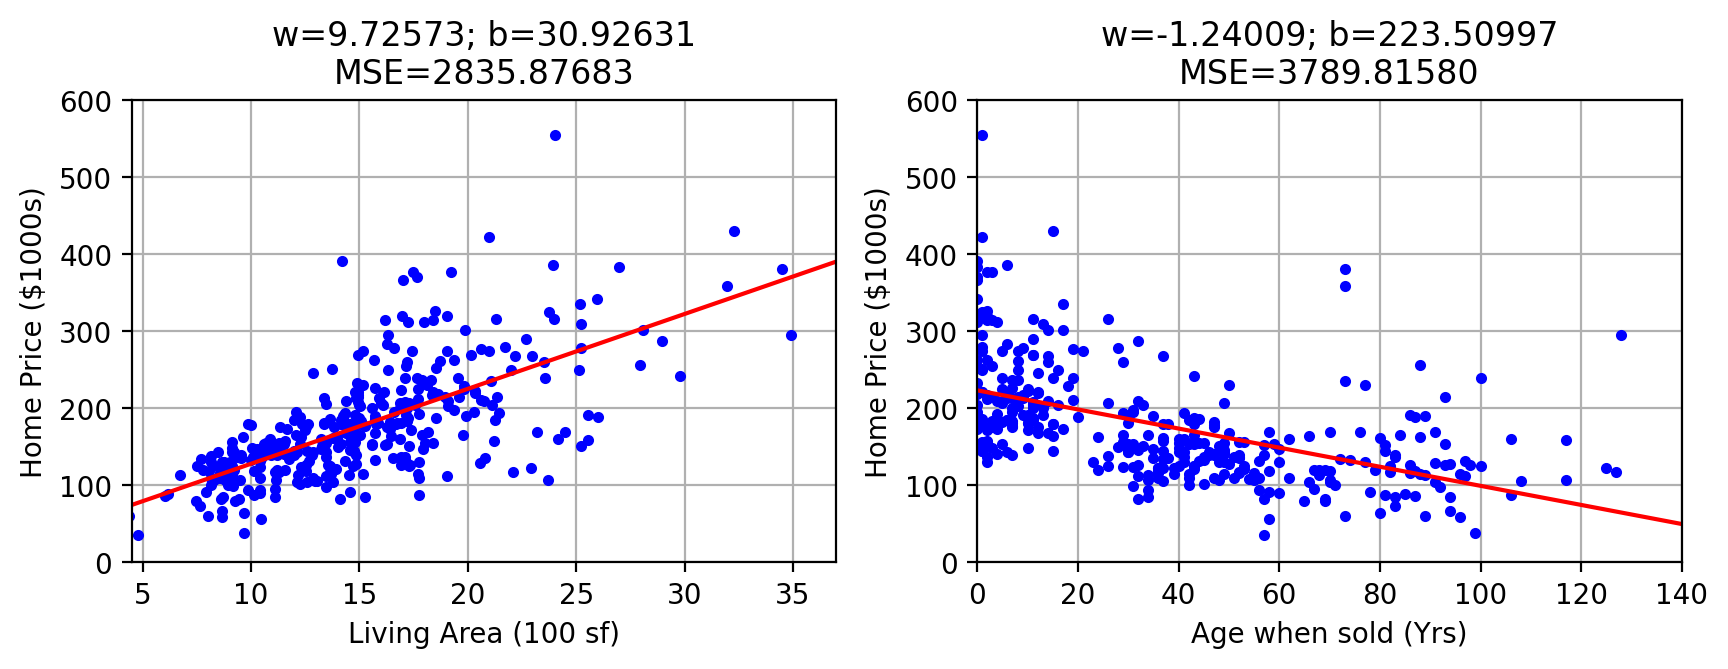

In [16]:
ofig

- for both features together

In [17]:
def plot_linear_2d(model, axbox, X, Y):
    xr = [linspace(axbox[0],axbox[1],100), 
          linspace(axbox[2],axbox[3],100)]
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    ypred = model.predict(allpts).reshape(xgrid0.shape)

    # calculate MSE
    MSE = metrics.mean_squared_error(Y, model.predict(X))

    # make figure
    vmin = Y.min()-1
    vmax = Y.max()+1
    
    # show the 2d function as an image
    plt.imshow(ypred, origin='lower', extent=axbox, aspect='auto', vmin=vmin, vmax=vmax, cmap='jet')
    plt.scatter(X[:,0], X[:,1], c=Y, vmin=vmin, vmax=vmax, edgecolors='k', cmap='jet')
    plt.grid(True); plt.axis(axbox)
    plt.title('w=[{:.5f},{:.5f}]; b={:.5f}\nMSE={:.5f}'.format
              (model.coef_[0], model.coef_[1], model.intercept_, MSE))

In [18]:
# learn with both dimensions
ols = linear_model.LinearRegression()
ols.fit(housingX, housingY);

In [19]:
# make figure
housingaxbox2 = housingaxbox[0][0:2] + housingaxbox[1][0:2]
ofig = plt.figure()
plot_linear_2d(ols, housingaxbox2, housingX, housingY)
cbar = plt.colorbar()
cbar.set_label(housingYname)
plt.xlabel(housingXname[0])
plt.ylabel(housingXname[1]);
plt.close()

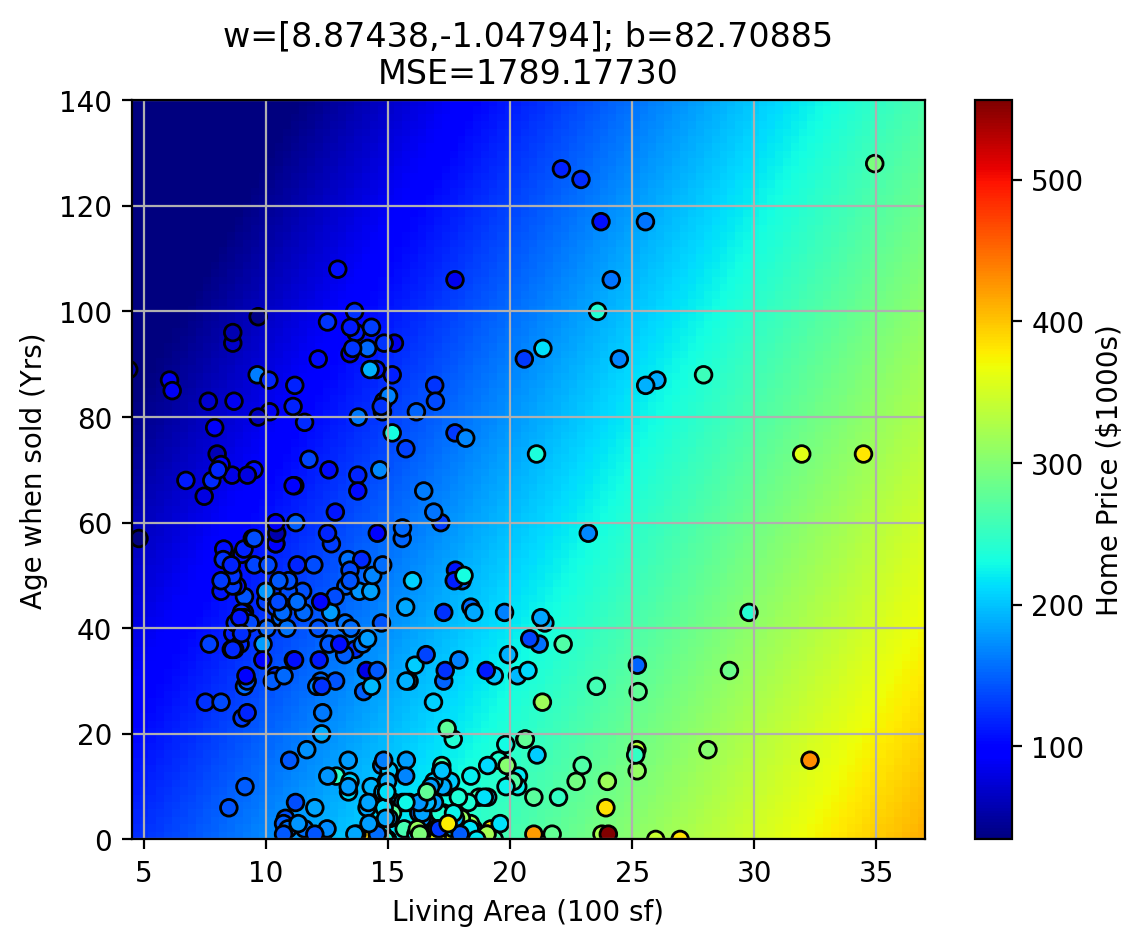

In [20]:
ofig

- interpretation from the linear model parameters:
  - each 100 sqf of living space increases home price by $\$$8874 ($w_1$)
  - each year of age decreases home price by $\$$1048 ($w_2$)
  - the "starting" price is $\$$82,709 ($b$).

# Selecting Features
- There are more features from the housing data.
  - plots of feature vs. housing price

In [21]:
housingX, housingY, housingXname, housingYname, housingaxbox, housingXdesc = load_housing(mode=2)

housingffig = plt.figure(figsize=(10,3))
for i in range(housingX.shape[1]):
    plt.subplot(2,6,i+1)
    plt.plot(housingX[:,i], housingY, 'b.')
    plt.grid(True)
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title(housingXname[i])
plt.tight_layout()
plt.close()

mydesc = ''
for i,j in zip(housingXname, housingXdesc):
    mydesc += '{:5s} = {}\n'.format(i, j)
print(mydesc)


target:  (365,) ; data:  (365, 12)
LiveA = Living Area (sqf)
Rooms = Number of Rooms
GaraA = Garage Area (sqf)
Bsmt  = Basement Area (sqf)
Fire  = Number of Fireplaces
Bdrms = Number of Bedrooms
Bath  = Number of Bathrooms
LotA  = Lot Area (sqf)
LowQA = Area of low-quality finish (sqf)
Qual  = Overall Quality of Materials
Cond  = Overall Condition
Age   = Age when Sold (yrs)



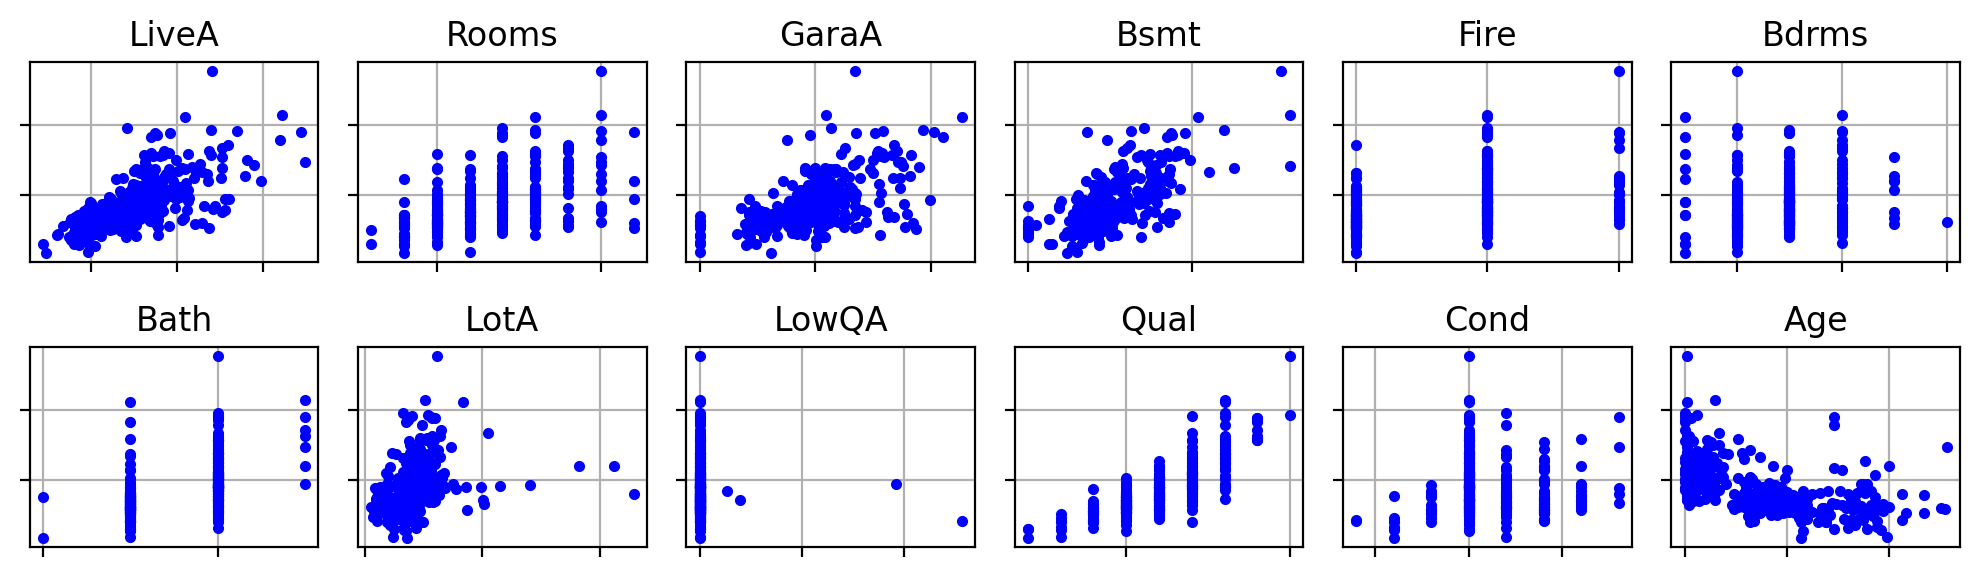

In [22]:
housingffig

In [23]:
print(mydesc)

LiveA = Living Area (sqf)
Rooms = Number of Rooms
GaraA = Garage Area (sqf)
Bsmt  = Basement Area (sqf)
Fire  = Number of Fireplaces
Bdrms = Number of Bedrooms
Bath  = Number of Bathrooms
LotA  = Lot Area (sqf)
LowQA = Area of low-quality finish (sqf)
Qual  = Overall Quality of Materials
Cond  = Overall Condition
Age   = Age when Sold (yrs)



- Use `pandas` to view pairwise relationships
  - diagonal shows the histogram
  - off-diagonal shows plots for two features at a time 

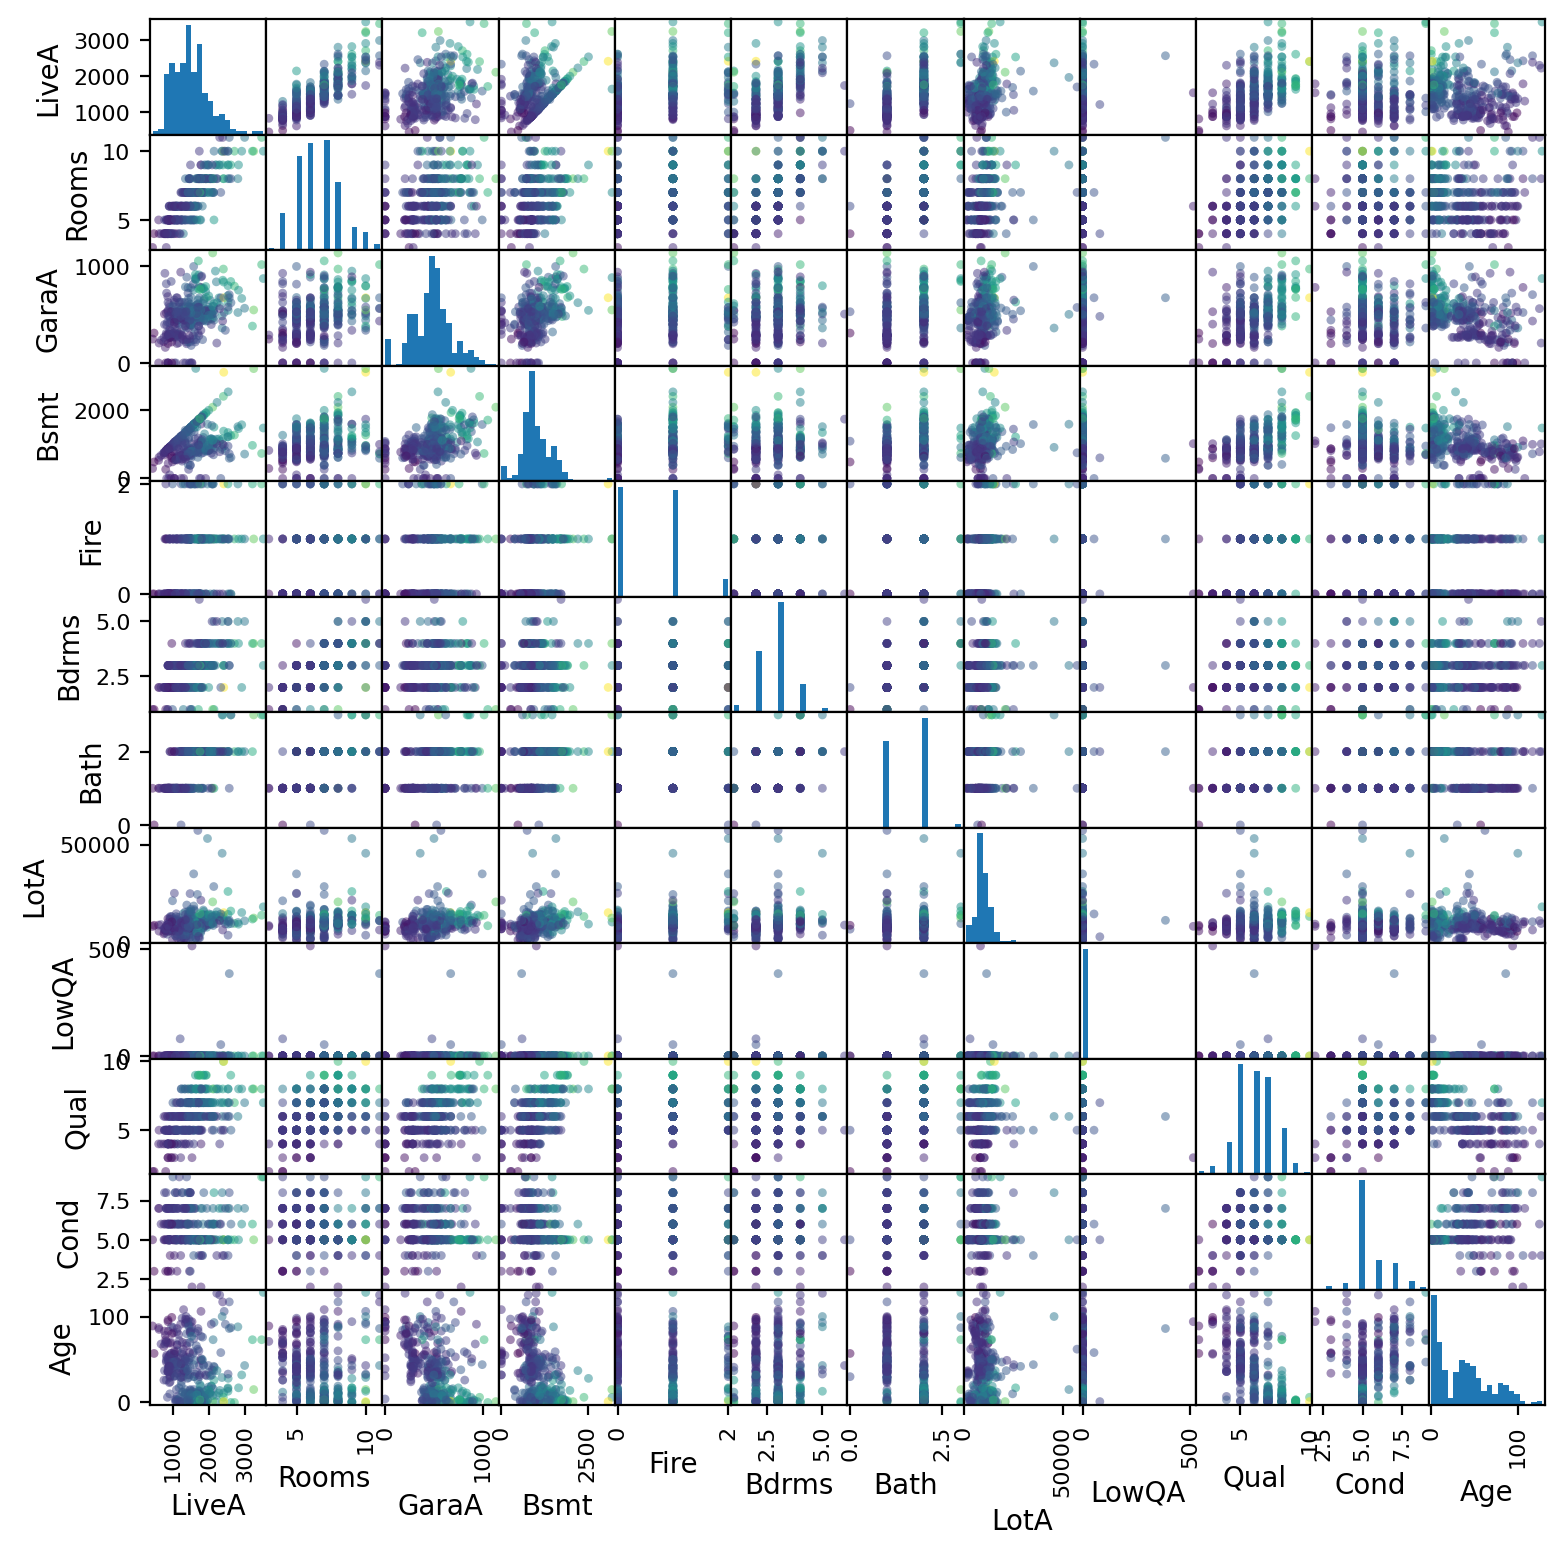

In [24]:
import pandas as pd
housing_df = pd.DataFrame(housingX, columns=housingXname)

tmp=pd.plotting.scatter_matrix(housing_df, c=housingY, figsize=(9, 9),
                              marker='o', hist_kwds={'bins': 20}, s=10,
                              alpha=.5)

- _Can we select a few features that are good for predicting the price?_
  - This will provide some insight about our data and what is important.

# Shrinkage
- Add a _regularization_ term to "shrink" some linear weights to zero.
  - features associated with zero weight are not important since they aren't used to calculate the function output.
  - $y = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_d x_d$

# Ridge Regression
- Add regularization term to OLS:
$$\min_{\mathbf{w},b} \alpha ||\mathbf{w}||^2 + \sum_{i=1}^N (y_i - f(\mathbf{x}_i))^2 $$
- the first term is the _regularization term_
  - $||\mathbf{w}||^2 = \sum_{j=1}^d w_j^2$ penalizes large weights (aka L2-norm)
  - $\alpha$ is the hyperparameter that controls the amount of shrinkage
    - larger $\alpha$ means more shrinkage.
    - $\alpha=0$ is the same as OLS.
- the second term is the _data-fit term_
  - sum-squared error of the prediction, same as linear regression.

- Also has a closed-form solution (similar derivation to linear regression):
  - $\mathbf{w}^* = (\mathbf{X}\mathbf{X}^T + \alpha I)^{-1}\mathbf{X}\mathbf{y}$
  - Similar to the solution for linear regression: $\mathbf{w}^* = (\mathbf{X}\mathbf{X}^T)^{-1}\mathbf{X}\mathbf{y}$
- What is the effect of the scaled identity matrix $\alpha I$?

In [25]:
# plot the class-conditional density
def plot_ccd(pdf, axbox, plot3d=False):
    
    if plot3d:
        N = 50
    else:
        N = 200
    
    xr = [ linspace(axbox[0], axbox[1], N), 
           linspace(axbox[2], axbox[3], N) ]

    # make a grid for calculating the posterior, 
    #  then form into a big [N,2] matrix
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]
    
    # calculate the posterior probability
    px = pdf(allpts)
    px1 = px.reshape(xgrid0.shape)

    if plot3d:
        #ax = plt.axes(projection='3d')
        ax = plt.gca()
        ax.plot_surface(xgrid0, xgrid1, px1, rstride=1, cstride=1,
                        cmap='viridis', edgecolor='none')        
    else:
        # show contour plot of density    
        plt.imshow(px1, origin='lower', extent=axbox, alpha=0.70, cmap=plt.get_cmap('Blues_r'))
        plt.contour(xr[0], xr[1], px1, linewidths=0.5, colors='k')  #cmap=plt.get_cmap('Blues_r'))

- with linear regression, if $\mathbf{X}$ does not span the input space $\mathbb{R}^d$, then $\mathbf{X}\mathbf{X}^T$ could be ill-conditioned or non-invertible.
  - i.e., we don't know how the data varies in the space orthogonal to $\mathbf{X}$.
- with ridge regression, the scaled identity conditions the matrix $\mathbf{X}\mathbf{X}^T$ so that the inverse can be computed.
  - (The term "ridge regression" comes from the closed-form solution, where a "ridge" is added to the diagonal of the covariance matrix)

In [26]:
degX = random.normal(size=[100,1])*[[1, 1]] + random.normal(0, 0.00001, size=[100,2])

degS = degX.T@degX
print(degS)
print(linalg.inv(degS))

regS = degS + 0.1*eye(2)
print(regS)
print(linalg.inv(regS))

[[110.59708802 110.59718209]
 [110.59718209 110.59727617]]
[[ 58852883.72198314 -58852833.65741637]
 [-58852833.65741637  58852783.60193399]]
[[110.69708802 110.59718209]
 [110.59718209 110.69727617]]
[[ 5.00226326 -4.99774014]
 [-4.99774014  5.00225476]]


In [27]:
from scipy.stats import multivariate_normal as mvn
degfig = plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.scatter(degX[:,0], degX[:,1], s=6)
plt.grid(True)
plt.title('$\mathbf{X}$ features')
plt.subplot(1,3,2)
plot_ccd(lambda x: mvn.pdf(x, mean=[0,0], cov=degS, allow_singular=True), [-3,3,-3,3])
plt.text(-2.5,2.5, "covariance", c='w', fontsize=8)
plt.text(-2.5,1.5,array2string(degS, precision=2), c='w', fontsize=8)
plt.text(-1.5,-2.5,array2string(linalg.inv(degS), precision=0), c='w', fontsize=8)
plt.text(0,-1.5, "inverse", c='w', fontsize=8)
plt.title('Gaussian w/ Cov $\mathbf{X}\mathbf{X}^T$')
plt.subplot(1,3,3)
plt.title('Gaussian w/ Cov $\mathbf{X}\mathbf{X}^T+0.1\mathbf{I}$')
plot_ccd(lambda x: mvn.pdf(x, mean=[0,0], cov=regS, allow_singular=True), [-3,3,-3,3])
plt.text(-2.5,2.5, "covariance", c='w', fontsize=8)
plt.text(-2.5,1.5,array2string(regS, precision=2), c='w', fontsize=8)
plt.text(0,-2.5,array2string(linalg.inv(regS), precision=3), c='w', fontsize=8)
plt.text(0,-1.5, "inverse", c='w', fontsize=8)
plt.close()


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_24218/1099640263.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.title('$\mathbf{X}$ features')
/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_24218/1099640263.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Gaussian w/ Cov $\mathbf{X}\mathbf{X}^T$')
/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_24218/1099640263.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Gaussian w/ Cov $\mathbf{X}\mathbf{X}^T+0.1\mathbf{I}$')


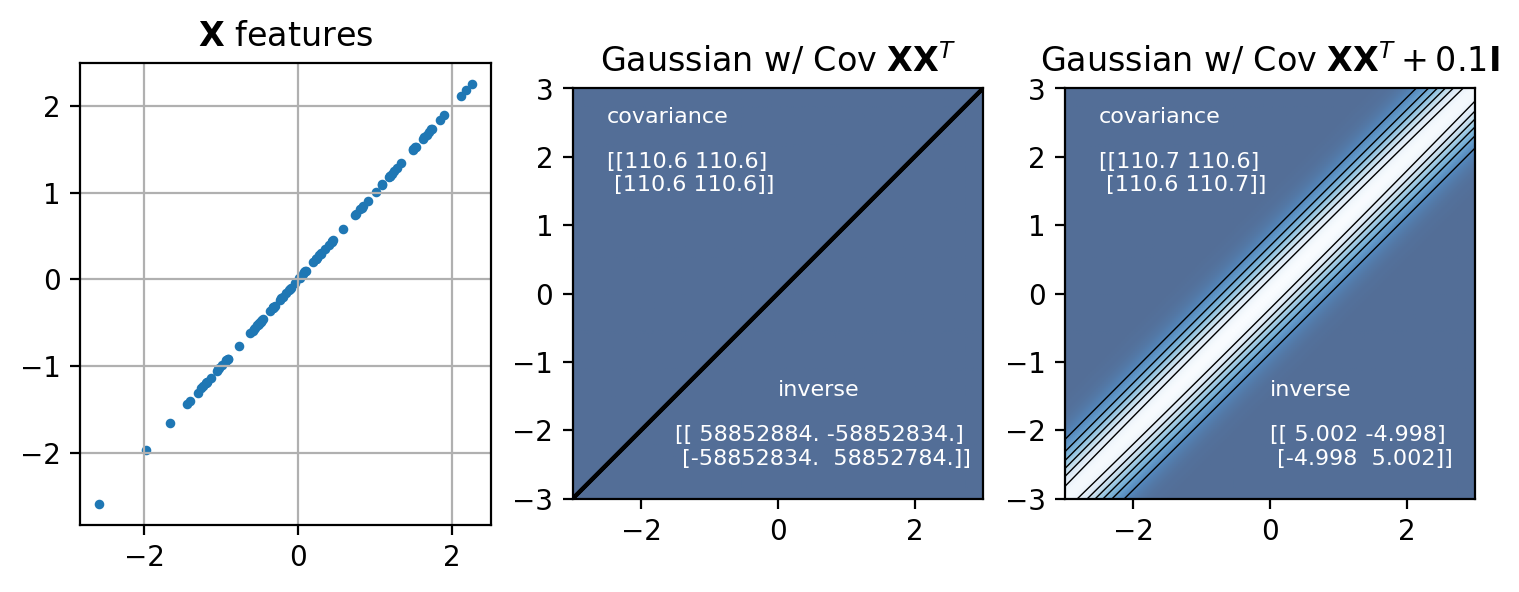

In [28]:
degfig

# Example on Housing data


In [29]:
# randomly split data into 80% train and 20% test set
trainX, testX, trainY, testY = \
  model_selection.train_test_split(housingX, housingY, 
  train_size=0.8, test_size=0.2, random_state=4487)

# normalize feature values to zero mean and unit variance
# this makes comparing weights more meaningful
#   feature value 0 means the average value for that features
#   feature value of +1 means one standard deviation above average
#   feature value of -1 means one standard deviation below average
scaler = preprocessing.StandardScaler()  
trainXn = scaler.fit_transform(trainX)  
testXn  = scaler.transform(testX)
    
print(trainXn.shape)
print(testXn.shape)

(292, 12)
(73, 12)


- vary $\alpha$ from $10^{-3}$ (little shrinkage) to $10^6$ (lots of shrinkage)

In [30]:
# alpha values to try
alphas = logspace(-3,6,50)

MSEs = empty(len(alphas))
ws   = empty((len(alphas), trainXn.shape[1]))
for i,alpha in enumerate(alphas):
    # learn the RR model
    rr = linear_model.Ridge(alpha=alpha)
    rr.fit(trainXn, trainY)
    ws[i,:] = rr.coef_   # save weights
    
    MSEs[i] = metrics.mean_squared_error(testY, rr.predict(testXn))

- Effect...
  - for small $\alpha$, all weights are non-zero.
  - for large $\alpha$, all weights shrink to 0.
  - somewhere in between is the best model...

In [31]:
rfig = plt.figure(figsize=(9,3))
plt.subplot(1,2,1)
plt.semilogx(alphas, ws)
plt.xlabel('$\\alpha$'); plt.ylabel('weight $w_j$')
plt.grid(True); plt.title("Ridge Regression")
plt.subplot(1,2,2)
plt.semilogx(alphas, MSEs)
plt.xlabel('$\\alpha$'); plt.ylabel('test MSE')
plt.axis([alphas[0], alphas[-1], 450, 1000])
plt.grid(True); plt.title('test MSE vs $\\alpha$');
plt.close()

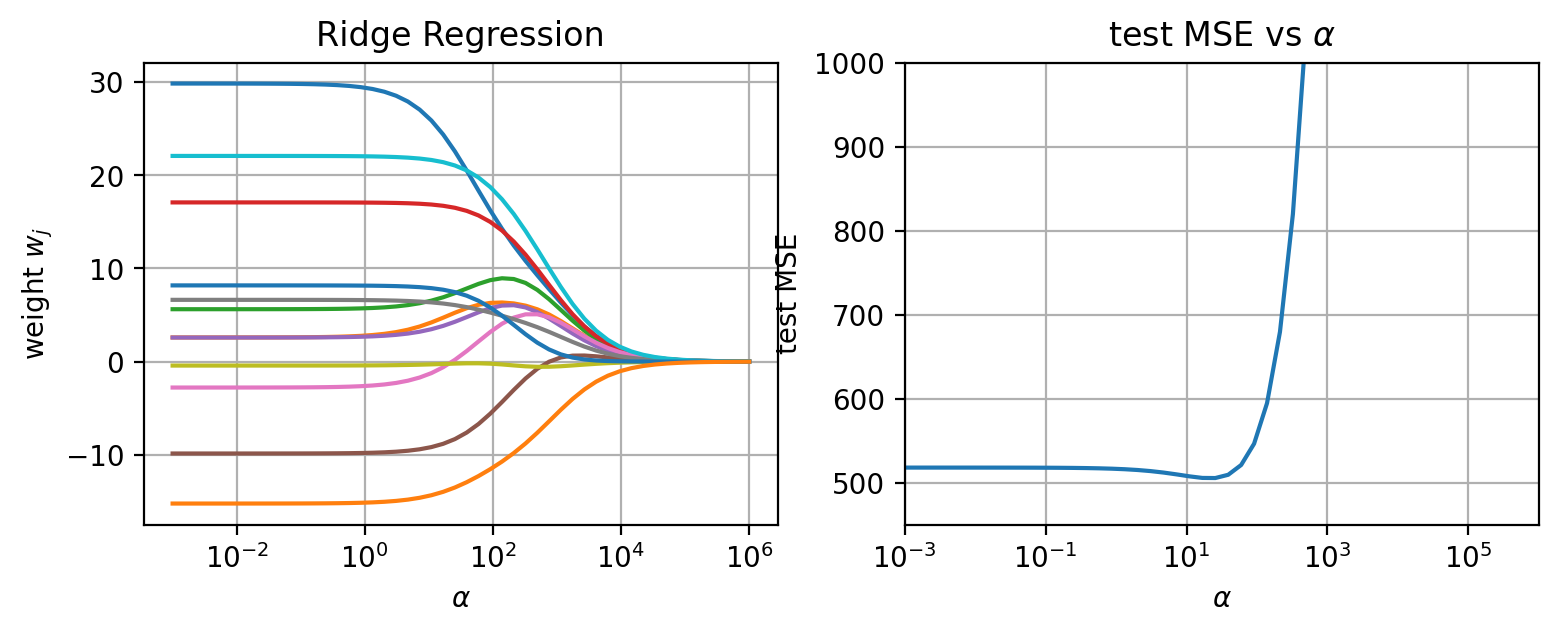

In [32]:
rfig

# Selecting $\alpha$ using cross-validation
- built-in cross-validation (RidgeCV)

In [33]:
# train RR with cross-validation
rr = linear_model.RidgeCV(alphas=alphas, cv=5)
rr.fit(trainXn, trainY)

MSE = metrics.mean_squared_error(testY, rr.predict(testXn))
print("MSE =", MSE)
print("alpha =", rr.alpha_)
print("w =", rr.coef_)

MSE = 509.73480239949345
alpha = 7.196856730011521
w = [ 27.0687271    3.7674307    6.26844302  16.95682861   3.20616604
  -9.42397403  -1.71271811   6.44770492  -0.33614936  21.81101743
   7.99606554 -14.63428106]


# Interpretation
- Which weights are most important?
  - look at weights with large magnitude.

In [34]:
# print out sorted coefficients with descriptions
def print_coefs(coefs, name, desc):
    # sort coefficients from smallest to largest, then reverse it
    inds = argsort(abs(coefs))[::-1]
    # print out
    print("weight : feature description")
    for i in inds:
        print("{: .3f} : {:5s} = {}".format(coefs[i], name[i], desc[i]))

- Which weights are most important?
  - positive weights indicate factors that increase the house price
    - *Examples:* LiveA, Qual, Bsmt, Cond
  - negative weights indicate factors that decrease the house price
    - *Examples:* Age, Bdrms, Bath


In [35]:
print_coefs(rr.coef_, housingXname, housingXdesc)

weight : feature description
 27.069 : LiveA = Living Area (sqf)
 21.811 : Qual  = Overall Quality of Materials
 16.957 : Bsmt  = Basement Area (sqf)
-14.634 : Age   = Age when Sold (yrs)
-9.424 : Bdrms = Number of Bedrooms
 7.996 : Cond  = Overall Condition
 6.448 : LotA  = Lot Area (sqf)
 6.268 : GaraA = Garage Area (sqf)
 3.767 : Rooms = Number of Rooms
 3.206 : Fire  = Number of Fireplaces
-1.713 : Bath  = Number of Bathrooms
-0.336 : LowQA = Area of low-quality finish (sqf)


# Better shrinkage
- With ridge regression, some weights are small but still non-zero.
  - these are less important, but somehow still necessary.
- To get better shrinkage to zero, we can change the regularization term to encourage more weights to be 0. 
  - also called "sparse" weights, or encouraging "sparsity".

# LASSO
- LASSO = "Least absolute shrinkage and selection operator"
- keep the same data fit term, but change the regularization term:
  - sum of absolute weight values: $\sum_{j=1}^d|w_j|$
    - also called L1-norm: $||\mathbf{w}||_1$
  - when a weight is close to 0, the regularization term can move the weight to be equal to 0.
$$\min_{\mathbf{w},b} \alpha \sum_{j=1}^d|w_j| + \sum_{i=1}^N (y_i - f(\mathbf{x}_i))^2 $$


# Comparison of L2 and L1 norms.
- L2 focuses more on large weights.
- L1 treats all weights equally.

In [36]:
x = linspace(-3,3,100)
normfig = plt.figure()
plt.plot(x,x**2, 'r-', label='L2-norm')
plt.plot(x,abs(x), 'b-', label='L1-norm')
plt.xlabel('w')
plt.ylabel('norm')
plt.grid(True)
plt.legend()
plt.annotate(text="focus more on\nlarge weights", 
             xy=(-2.5,6.25), xytext=(-1.8,7.5), backgroundcolor='white', 
            arrowprops=dict(arrowstyle="->"))

plt.annotate(text="focus less on\nsmall weights", 
             xy=(0.5,.25), xytext=(1.5,.25), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))

plt.annotate(text="", 
             xy=(-.5,.5), xytext=(-0.5,4.5), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.annotate(text="focus equally on small\nand large weights.\nallows small weights\nto go to 0.", 
             xy=(-2,2), xytext=(-1,4.5), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))


plt.close()

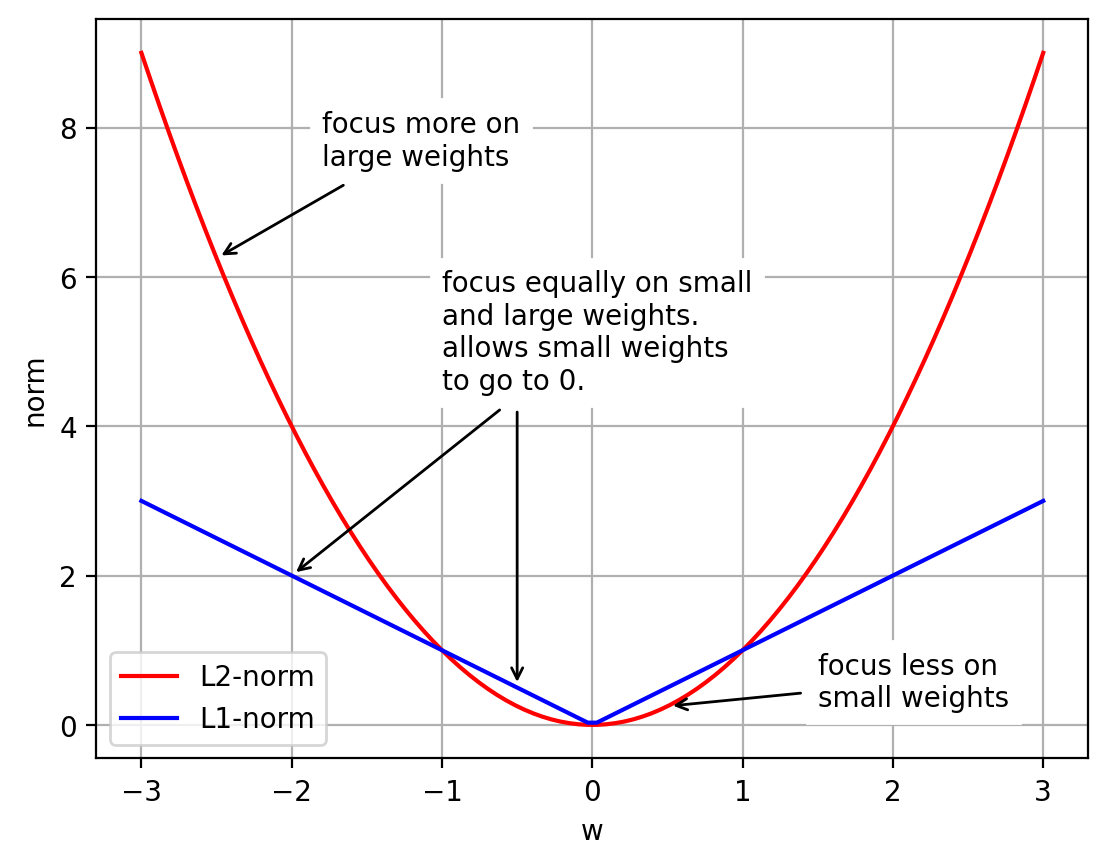

In [37]:
normfig

# Comparison of L2 and L1 norms
- During optimization with L1 norm:
  - for a given value of L1 norm, the minimal objective is usually in a "corner" of the L1 norm contour.
  - The "corner" corresponds to some weights equal to 0.
  
<center>
<table>
<tr><td>L1</td><td>L2</td></tr>
<tr><td>
<img src="imgs/l1.png" width=400>
</td><td>
<img src="imgs/l2.png" width=400>
</td></tr></table>
</center>

In [38]:
lasalphas = logspace(-3,2,50)

lassoMSEs  = empty(len(alphas))
lassows   = empty((len(alphas), trainXn.shape[1]))
for i,alpha in enumerate(lasalphas):
    # learn the LASSO model
    las = linear_model.Lasso(alpha=alpha)
    las.fit(trainXn, trainY)
    lassows[i,:] = las.coef_   # save weights
    
    lassoMSEs[i] = metrics.mean_squared_error(testY, las.predict(testXn))

In [39]:
lfig = plt.figure(figsize=(9,3))
plt.subplot(1,2,1)
plt.semilogx(lasalphas, lassows)
plt.xlabel('$\\alpha$'); plt.ylabel('weight $w_j$')
plt.grid(True)
plt.title('LASSO')
plt.subplot(1,2,2)
plt.semilogx(lasalphas, lassoMSEs)
plt.xlabel('$\\alpha$'); plt.ylabel('MSE')
plt.axis([lasalphas[0], lasalphas[-1], 450, 1000])
plt.grid(True)
plt.title('test MSE')
plt.close()

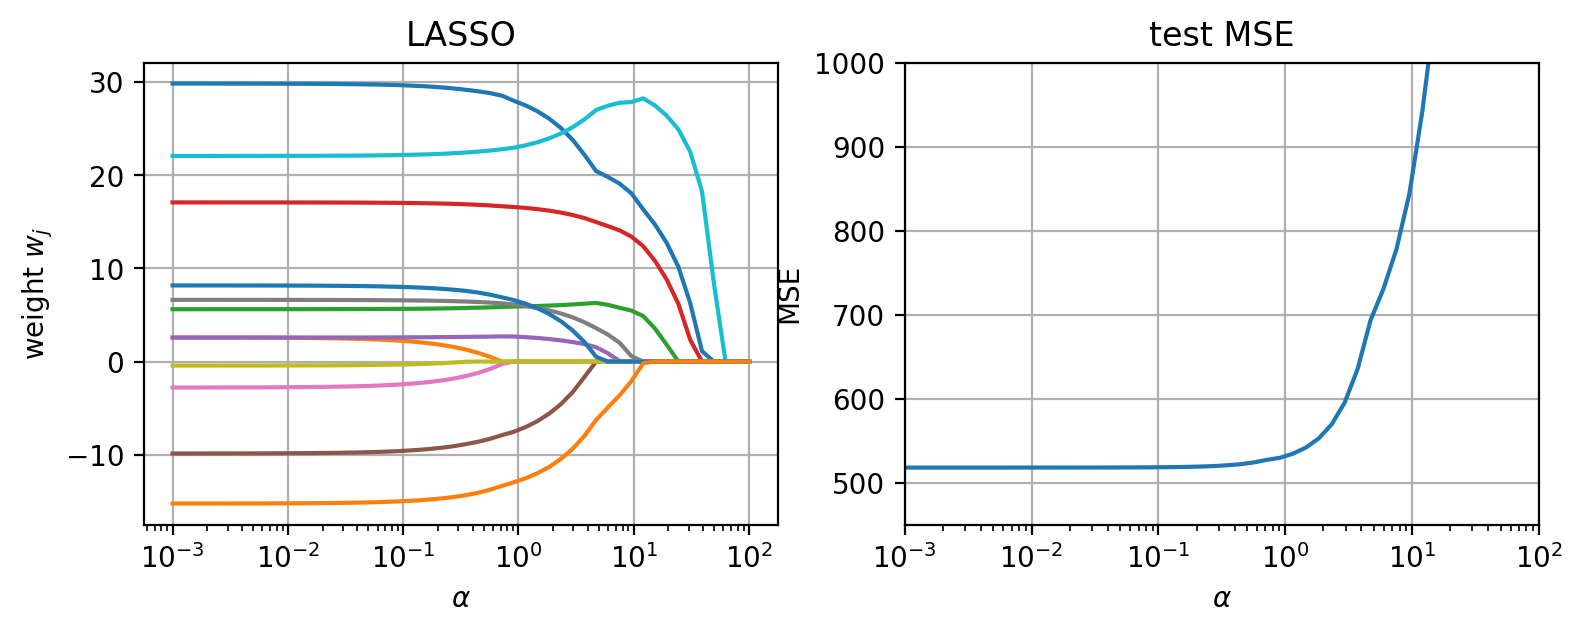

In [40]:
lfig

# Feature selection
- Select $\alpha$ to obtain a given number of features

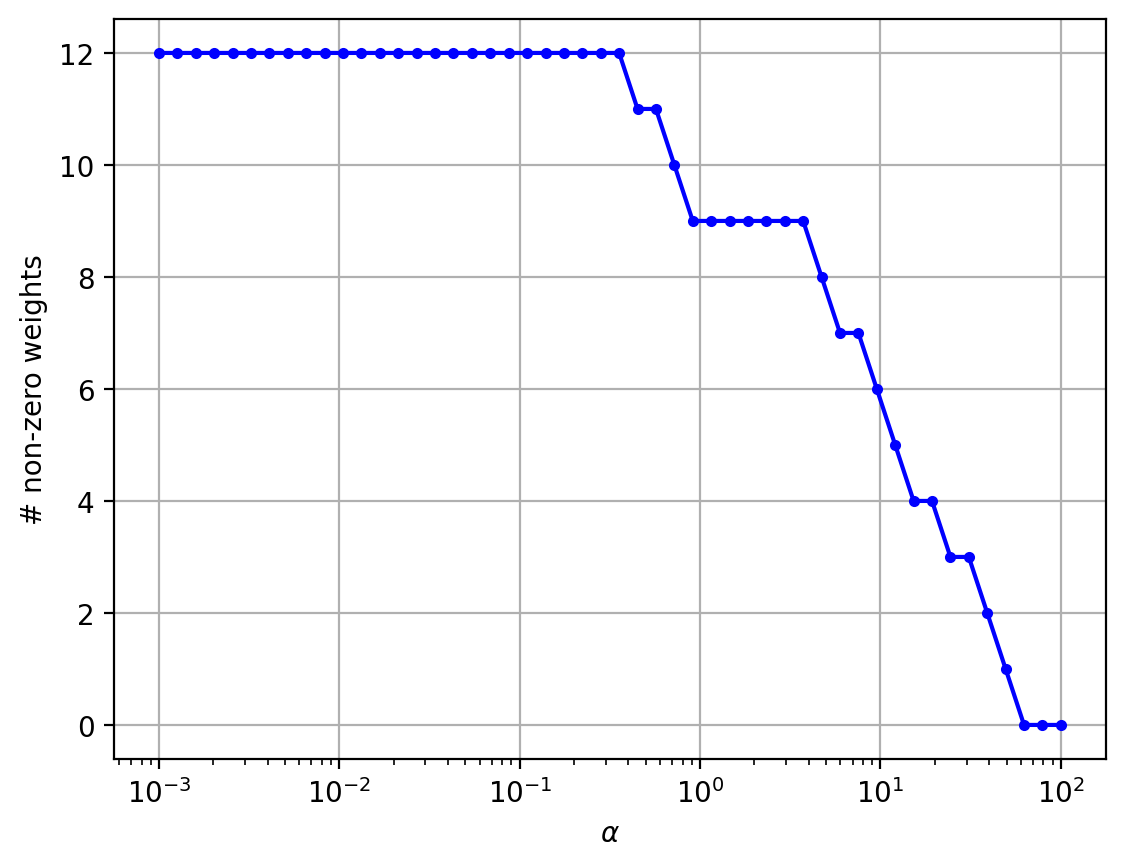

In [41]:
# count the number of non-zero weights
nzweights = sum(abs(lassows)>1e-6, axis=1)

plt.semilogx(lasalphas, nzweights, 'b.-')
plt.grid(True)
plt.xlabel('$\\alpha$'); plt.ylabel('# non-zero weights');

In [42]:
# get alpha where non-zero weights = 5
myi = where(nzweights==5)[0][0]
print("alpha=", lasalphas[myi])
print("MSE =", lassoMSEs[myi])
print("w =", lassows[myi,:])

alpha= 12.067926406393289
MSE = 941.847017977837
w = [16.35781583  0.          4.89090713 12.39985828  0.         -0.
  0.          0.         -0.         28.27633526  0.         -0.17302193]


## Interpretation
- important features have non-zero weights
  - Qual, LiveA, Bsmt, GaraA, Age
- weights for unimportant features are set to 0
  - Cond, LowQA, LotA, Bath, Bdrms, Fire, Rooms



In [43]:
print_coefs(lassows[myi,:], housingXname, housingXdesc)

weight : feature description
 28.276 : Qual  = Overall Quality of Materials
 16.358 : LiveA = Living Area (sqf)
 12.400 : Bsmt  = Basement Area (sqf)
 4.891 : GaraA = Garage Area (sqf)
-0.173 : Age   = Age when Sold (yrs)
 0.000 : Cond  = Overall Condition
-0.000 : LowQA = Area of low-quality finish (sqf)
 0.000 : LotA  = Lot Area (sqf)
 0.000 : Bath  = Number of Bathrooms
-0.000 : Bdrms = Number of Bedrooms
 0.000 : Fire  = Number of Fireplaces
 0.000 : Rooms = Number of Rooms


# Cross-validation to select $\alpha$
- Use built-in CV function
  - selects $\alpha$ with lowest error.

In [44]:
# fit with cross-validation (alpha range is determined automatically)
las = linear_model.LassoCV()
las.fit(trainXn, trainY)

MSE = metrics.mean_squared_error(testY, las.predict(testXn))
print("MSE =", MSE)
print("alpha =", las.alpha_)
print("w =", las.coef_)

MSE = 527.9102135105119
alpha = 0.8213828052493435
w = [ 28.20284029   0.           5.90009657  16.64554095   2.71954575
  -7.72793088  -0.           6.19124241  -0.          22.87482329
   6.74864601 -13.12006246]


## Interpretation
- LowQA, Bath, Rooms are unimportant features

In [45]:
print_coefs(las.coef_, housingXname, housingXdesc)

weight : feature description
 28.203 : LiveA = Living Area (sqf)
 22.875 : Qual  = Overall Quality of Materials
 16.646 : Bsmt  = Basement Area (sqf)
-13.120 : Age   = Age when Sold (yrs)
-7.728 : Bdrms = Number of Bedrooms
 6.749 : Cond  = Overall Condition
 6.191 : LotA  = Lot Area (sqf)
 5.900 : GaraA = Garage Area (sqf)
 2.720 : Fire  = Number of Fireplaces
-0.000 : LowQA = Area of low-quality finish (sqf)
-0.000 : Bath  = Number of Bathrooms
 0.000 : Rooms = Number of Rooms


# Sparsity Constraints

- In previous formulations, LASSO and Ridge Regression only encourage sparisty using a regularizer.
- We can also formulate the regression problem with *explicit* sparsity constraints:
$$ \min_{\mathbf{w},b} \sum_{i=1}^N (y_i - f(\mathbf{x}_i))^2, \mathrm{s.t.}\ ||\mathbf{w}||_0 \leq K $$
  - L0-norm: $||\mathbf{w}||_0$ = the number of non-zero entries in $\mathbf{w}$.
    - (not really a norm)
  - $K$ is a hyperparameter - how many non-zero coefficients are desired.

# Serious problem...
- LASSO and Ridge Regression are convex problems
  - Ridge Regression - closed-form solution
  - LASSO - efficient optimization algorithms to get exact solution
- Optimization problems with L0-norm constraints are NP-hard.
  - Combinatorial problem - all combinations of features need to be tried.

# Orthogonal Matching Pursuit (OMP)

- **Idea:** greedy algorithm that iteratively selects the feature that is most correlated with the current residual error.
- Algorithm
  - Initialize the residual: $\mathbf{r} = \mathbf{y}$
  - For $t$ in 1 to $K$
    - Find the most correlated feature: $j = \mathop{\mathrm{argmax}}_j | \mathbf{r}^T \mathbf{x}_j |$, where $\mathbf{x}_j$ is the j-th row of $\mathbf{X}$ (the j-th features).
    - Compute the weight: $w_j = \mathop{\mathrm{argmin}}_{w_j} ||\mathbf{r} - \mathbf{x}_j w_j||^2$
    - Update the residual: $\mathbf{r} -= \mathbf{x}_j w_j$

In [47]:
# Example
omp = linear_model.OrthogonalMatchingPursuit(n_nonzero_coefs=2) # normalize=False
omp.fit(trainXn, trainY)

MSE = metrics.mean_squared_error(testY, omp.predict(testXn))
print("MSE =", MSE)
print(omp.coef_)
print(omp.intercept_)

MSE = 1161.3764110385423
[26.78089631  0.          0.          0.          0.          0.
  0.          0.          0.         43.93862629  0.          0.        ]
180.67125342465755


In [48]:
print_coefs(omp.coef_, housingXname, housingXdesc)

weight : feature description
 43.939 : Qual  = Overall Quality of Materials
 26.781 : LiveA = Living Area (sqf)
 0.000 : Age   = Age when Sold (yrs)
 0.000 : Cond  = Overall Condition
 0.000 : LowQA = Area of low-quality finish (sqf)
 0.000 : LotA  = Lot Area (sqf)
 0.000 : Bath  = Number of Bathrooms
 0.000 : Bdrms = Number of Bedrooms
 0.000 : Fire  = Number of Fireplaces
 0.000 : Bsmt  = Basement Area (sqf)
 0.000 : GaraA = Garage Area (sqf)
 0.000 : Rooms = Number of Rooms


- Note that LASSO selects the same features, but has worse MSE (due to regularization on the weights).

In [49]:
# get alpha where non-zero weights = 2
myi = where(nzweights==2)[0][0]
print("MSE =", lassoMSEs[myi])
print_coefs(lassows[myi,:], housingXname, housingXdesc)

MSE = 2812.848239318136
weight : feature description
 18.287 : Qual  = Overall Quality of Materials
 1.129 : LiveA = Living Area (sqf)
-0.000 : Age   = Age when Sold (yrs)
 0.000 : Cond  = Overall Condition
-0.000 : LowQA = Area of low-quality finish (sqf)
 0.000 : LotA  = Lot Area (sqf)
 0.000 : Bath  = Number of Bathrooms
 0.000 : Bdrms = Number of Bedrooms
 0.000 : Fire  = Number of Fireplaces
 0.000 : Bsmt  = Basement Area (sqf)
 0.000 : GaraA = Garage Area (sqf)
 0.000 : Rooms = Number of Rooms
